### Simulating Euclid 2D spectra with GELSA 

We take the sources from the catalog **EDFN_deep.fits**

In [32]:
!hostname

mtx37


In [33]:
import sys
from gelsa import visu

In [34]:
from profile_fitter import Profile_Fitter
from spectra_generator import Spectra_Generator

In [38]:
galaxy.Galaxy.set_flux_Ha?

Signature: galaxy.Galaxy.set_flux_Ha(self, flux_Ha=1e-15, NII_Ha_ratio=0.2)
File:      ~/miniconda3/envs/tf/lib/python3.9/site-packages/gelsa/galaxy.py
Type:      function

In [36]:
from matplotlib import pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from gelsa import Gelsa
from gelsa import analysis
from gelsa import galaxy
from gelsa import visu

from astropy.io import fits
from astropy.table import Table
from astropy.constants import c
import astropy.units as u
import astropy.coordinates as coord
import astroquery 

from astroquery.vizier import Vizier

filename = "/scratch/astro/nicolo.fiaba/EDFN_deep.fits"
hdu_list = fits.open(filename, memmap=True)

In [5]:
data = Table(hdu_list[1].data)

### Remove NaNs from the data

In [6]:
has_nan = np.zeros(len(data), dtype=bool)
for col in data.itercols():
    if col.info.dtype.kind == 'f':
        has_nan |= np.isnan(col)
data_nonan = data[~has_nan]
data = data_nonan

In [7]:
pointing_filename = "/scratch/astro/nicolo.fiaba/pointing_list.txt"
pointings = Table.read(pointing_filename, format='ascii')

In [8]:
Spectra_Generator.generate_sources?

Signature: Spectra_Generator.generate_sources(self, det_n=None)
Docstring: Generate spectra for one specific detector (0–15) or the entire FOV (all 16).
File:      ~/codes/spectra_generator.py
Type:      function

In [9]:
import multiprocessing
print("number of CPUs: ", multiprocessing.cpu_count())

number of CPUs:  192


In [10]:
smj_centers = [5, 15, 20, 25, 30, 35, 45, 50]

In [11]:
if 'pt1_coeffs' not in globals():
    pt1_coeffs = [[ 1.77234446e-03,  2.53673518e+00],
       [ 4.07338437e-03,  1.87170864e+00],
       [ 1.12526831e-02,  2.08003500e+00],
       [ 2.32253015e-02,  1.71388283e+00],
       [ 1.17772560e-02,  1.50861189e+00],
       [ 2.39869540e-03,  1.78675470e+00],
       [-3.13389171e-02,  2.95207141e+00],
       [-5.49549843e-02,  3.87116259e+00],
       [ 5.49966246e-03,  1.92784429e+00],
       [ 1.39497894e-02,  1.96737090e+00],
       [ 1.04667474e-02,  1.62507997e+00],
       [ 1.06938595e-02,  1.35771835e+00],
       [ 2.33678708e-02,  1.22726095e+00],
       [-3.74385235e-02,  3.39684561e+00],
       [ 8.18984806e-03,  2.04066593e+00],
       [-1.00264718e-03,  2.30374499e+00]]

We manually set a threshold on the *kron_radius* value: all sources with kron_radius larger than 20 pixels (or 2 arcsec) are removed from the catalog.
**Edit: no more!**

In [12]:
# mask = data['KRON_RADIUS'] <= 20
# filtered_data = data[mask]
G = Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                        calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)

The **flux** values are in $\mu Jy$ (microJansky), so they need to be converted into $erg \ s^{-1} \ cm^{-2} \ angstrom^{-1}$.

$1 \ \mu Jy = 10^{-29} \ erg \ s^{-1} \ cm^{-2} \ Hz^{-1}$

For energy conservation: $f_\lambda \ d\lambda = f_\nu \ d\nu$

So: $f_\lambda = f_\nu \ |\frac{d \nu}{d \lambda}| = f_\nu \ \frac{c}{\lambda^2}$

NB: c must be written in $angstrom \ s^{-1}$

>Center band values taken from: *Jahnke, K., et al. "Euclid-III. The NISP Instrument." Astronomy & Astrophysics 697 (2025): A3.*

In [13]:
c_cgs = c.cgs.value

# I compute the conversion factor c/lambda^2
factor = lambda lam: (c_cgs*1e8)/(lam**2)

# Center wavelength values in angstrom
j_center =  13673
h_center = 17714

continuum_wavelength = np.linspace(12000, 19000, 100)

For every pointing I generate a frame. Then I check which sources are matching that ID value and I put those sources in the frame.

In [14]:
# first, I convert the fluxes to erg s^-1 cm^-2 Hz^-1
flux_y_nu = 1e-29*data["FLUX_Y_TEMPLFIT_MWCORR"]
flux_j_nu = 1e-29*data["FLUX_J_TEMPLFIT_MWCORR"]
flux_h_nu = 1e-29*data["FLUX_H_TEMPLFIT_MWCORR"]
    
flux_j_lam = flux_j_nu * factor(j_center)
flux_h_lam = flux_h_nu * factor(h_center)

# Take the absolute value so we don't encounter problems in the computation of the log
flux_j_lam = np.abs(flux_j_lam)
flux_h_lam = np.abs(flux_h_lam)

log_j_flux = np.log10(flux_j_lam)
log_h_flux = np.log10(flux_h_lam)

axis_ratio = 1 - data['ELLIPTICITY']

# Find the FWHM from the SEMI-MAJOR AXIS using the relationship we found for that specific detector
# multiply by 0.1 to convert from pixels to arcsec
# def fit_line(x, coeffs):
#     return coeffs[0]*x + coeffs[1]

# fwhm_arcsec = fit_line(data["SEMIMAJOR_AXIS"], coeffs=pt1_coeffs[0]) * 0.1

In [15]:
# Add the axis_ratio to the Table
data["AXIS_RATIO"] = axis_ratio

In [16]:
x1, x2 = j_center, h_center
y1, y2 = np.array(log_j_flux), np.array(log_h_flux)

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

# Now compute y-values (fluxes) for all continuum wavelengths
fluxes = m[:, None] * continuum_wavelength[None, :] + b[:, None]
fluxes = np.array(fluxes)
print(fluxes.shape)

(2743701, 100)


### Simulating **emission lines**

In [20]:
# Specify the detector number you want to simulate 
# det_number = 0

"""
If no detector number is provided, all detectors will be simulated in parallel. 
In that case make sure to allocate 16 CPUs on the cluster
""";

In [21]:
%%time
SG = Spectra_Generator(pointings = pointings, 
                       data = data, 
                       continuum_wavelength = continuum_wavelength, 
                       pt_n = 18, 
                       fluxes = fluxes, 
                       fit_coeffs = pt1_coeffs)
frames = SG.generate_sources()#det_n = det_number)

loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml
143776 sources in pointing number 18 (1 degree from center)
Currently simulating sources in the entire FOV
Simulating 3933 sources in detector 0



alert weight=2.17328


Simulating 3891 sources in detector 1



alert weight=5.77623
alert weight=3.435186


Simulating 4689 sources in detector 2



...

Simulating 3808 sources in detector 12



alert weight=7.068342
alert weight=1.292326


Simulating 3962 sources in detector 13

Simulating 3988 sources in detector 14

Simulating 4677 sources in detector 15



alert weight=4.75157
alert weight=1.264492
alert weight=1.23098


CPU times: user 18.4 s, sys: 29.5 s, total: 47.9 s
Wall time: 1min 28s


In [22]:
frames = np.array(frames)
frames.shape

(16,)

In [45]:
# SG.export_images_to_file(frames, pt_id = 30477)

Added detector 0 to fits file
Added detector 1 to fits file
Added detector 2 to fits file
Added detector 3 to fits file
Added detector 4 to fits file
Added detector 5 to fits file
Added detector 6 to fits file
Added detector 7 to fits file
Added detector 8 to fits file
Added detector 9 to fits file
Added detector 10 to fits file
Added detector 11 to fits file
Added detector 12 to fits file
Added detector 13 to fits file
Added detector 14 to fits file
Added detector 15 to fits file

 Saved images to /scratch/astro/nicolo.fiaba/simulated_images/simulated_images_30477.fits


---

In [23]:
images = []
detectors = []

for fr in frames:
    for det in fr._data.keys():
            image, var, mask = fr.get_detector(det)
            images.append(image)
            detectors.append(det)
    
images = np.array(images)
detectors = np.array(detectors)

In [30]:
images[0]

(2040, 2040)

In [20]:
images_full = images[::2]
detectors_full = detectors[::2]

In [32]:
flux_mask = filtered_data["FLUX_H_TEMPLFIT_MWCORR"] > 100
masked_data_f = filtered_data[flux_mask]
len(masked_data_f)

40200

In [38]:
x1, y1, det1 = frames[0].radec_to_pixel(masked_data_f["RIGHT_ASCENSION"], masked_data_f["DECLINATION"], wavelength=12000)
x2, y2, det2 = frames[0].radec_to_pixel(masked_data_f["RIGHT_ASCENSION"], masked_data_f["DECLINATION"], wavelength=19000)

In [29]:
images[0].min()

np.float64(0.0)

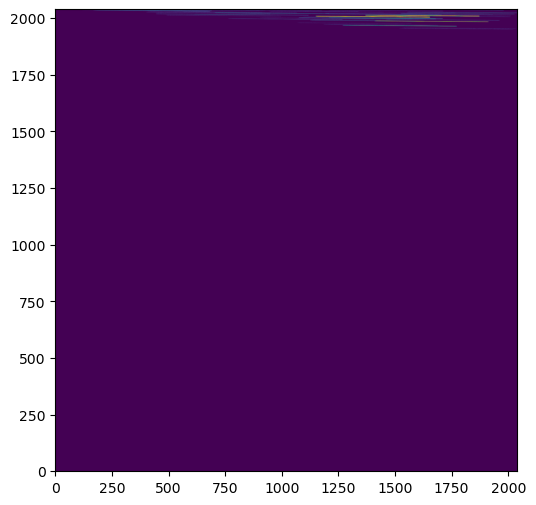

In [35]:
from gelsa import visu

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(visu.normalize_image(images[0], levels=(5, 99.95)), origin='lower')

# ax.scatter(x1[det1 == 0], y1[det1 == 0], c='red', s=20, marker='x', label=r"$\lambda = 12000 \ ang$")
# ax.scatter(x2[det2 == 0], y2[det2 == 0], c='orange', s=20, marker='x', label=r"$\lambda = 19000 \ ang$")

# ax.set_title('Detector number {}'.format(detectors[1]))
# ax.set_xlim(1500, 2040)
# ax.set_ylim(1950, 2040)

(np.float64(65.6223039117756),
 np.float64(67.82128063053518),
 np.float64(266.6459594132052),
 np.float64(268.8434481593877))

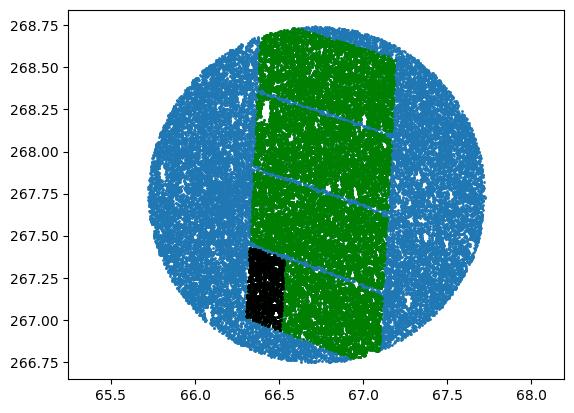

In [92]:
plt.scatter(temp_table["DECLINATION"], temp_table["RIGHT_ASCENSION"], s=1)
plt.scatter(temp_table2["DECLINATION"], temp_table2["RIGHT_ASCENSION"], s=1, c='green')
plt.scatter(temp_table_first["DECLINATION"], temp_table_first["RIGHT_ASCENSION"], s=1, c='k')
plt.axis('equal')

Here we replicate the 8 pixels next to the top and right border of the image, so that we achieve the desired 2048x2048 size, which is optimal for rectangular tiling.

for fr in frames:
    xl, yl, detl = frame.frame.radec_to_pixel(filtered_data["RIGHT_ASCENSION"], filtered_data["DECLINATION"], wavelength=12000)
    xr, yr, detr = frame.radec_to_pixel(filtered_data["RIGHT_ASCENSION"], filtered_data["DECLINATION"], wavelength=19000)

In [96]:
hdus = [fits.PrimaryHDU()]
    
# Append all image HDUs
for i, img in zip(detectors_full, images_full):
    hdus.append(fits.ImageHDU(img, name=f"DET{i}"))

# Write to FITS file once, after the loop
hdul = fits.HDUList(hdus)
hdul.writeto("simulated_detectors.fits", overwrite=True)

!jupyter nbconvert --to script simulation_full_dataset.ipynb

In [ ]:
from gelsa import visu

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(visu.normalize_image(padded_images[-2], levels=(5, 95)), 
          origin='lower')

left_det_1 = det1 == 0
right_det_1 = det2 == 0

ax.scatter(x1[left_det_1], y1[left_det_1], c='red', s=5, marker='x', label=r"$\lambda = 12000 \ ang$")
ax.scatter(x2[right_det_1], y2[right_det_1], c='white', s=5, marker='x', label=r"$\lambda = 19000 \ ang$")

ax.set_aspect('equal')

ax.set_xlim(0, 512)
ax.set_ylim(0, 512)
# plt.savefig("det1.png")
ax.legend(loc='lower right')
plt.tight_layout()

plt.show()

Now we can prepare the rectangular patches we can train the NN on

They're $32 \times 512$ tiles

def crop_into_rectangular_patches(img, patch_height, patch_width):
    h, w = img.shape
    # only keep the region that is divisible by patch size
    h_crop = (h // patch_height) * patch_height
    w_crop = (w // patch_width) * patch_width
    img_cropped = img[:h_crop, :w_crop]

    # reshape into patches
    patches = (
        img_cropped
        .reshape(h_crop // patch_height, patch_height, w_crop // patch_width, patch_width) 
        # the shape now is: (number of vertical patches, height of the vertical patch, # horizontal patches, width)
        .swapaxes(1, 2) # swap axis 1 with axis 2 so we have (numb, numb, height, width)
        .reshape(-1, patch_height, patch_width)
    )
    return patches

rect_images = []

patches = crop_into_rectangular_patches(img_padded, 32, 512)
rect_images.append(patches)

rect_images = np.array(rect_images)

rect_images.shape

rect_images = rect_images.reshape(-1, 32, 512)
rect_images.shape

Now we remove the blank rectangular images

mask = ~(rect_images == 0).all(axis=(1, 2))
nonzero_images = rect_images[mask]
nonzero_images.shape

plt.imshow(nonzero_images[89])

Save the images into a **fits** file

hdus = [fits.PrimaryHDU()]

# Append all image HDUs
for i, img in tqdm(enumerate(nonzero_images)):
    hdus.append(fits.ImageHDU(img, name=f"DET{i}"))

# Write to FITS file once, after the loop
hdul = fits.HDUList(hdus)
hdul.writeto("simulated_rectangular_images.fits", overwrite=True)

hdu_list_sim = fits.open("simulated_rectangular_images.fits", memmap=True)

fig, axs = plt.subplots(6, 11, figsize=(11, 3), tight_layout = True)

for i, ax in enumerate(axs.reshape(-1)):
    ax.imshow(hdu_list_sim[i+1].data, aspect=1, vmin=0, vmax=20)
    ax.axis('off')

img_data = np.array([hdu.data for hdu in hdu_list_sim[1:]])

img_data.shape